<a href="https://colab.research.google.com/github/znr6s28ynr-maker/Econometrics-Work/blob/main/03_Least_Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Rachel Wiggins**
ECON 6550
Assignment 3

## Showing that the sample regression line goes through the sample means of the independent and dependent variables

We start with the matrix representation of the linear regression model:

\begin{equation}
\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}
\end{equation}

Or, as shown in the last assignment:

\begin{equation}
y_i
=
𝛽_0 + 𝛽_1x_{1,i} + 𝛽_2x_{2,i} + ... + 𝛽_kx_{k,i}
+
\epsilon_i
\end{equation}

After the coefficients are estimated using the samples, the fitted regression becomes:

\begin{equation}
\hat{y_i}
=
\hat{b_0} + \hat{b_1}x_{1,i} + \hat{b_2}x_{2,i} + ... + \hat{b_k}x_{k,i}
\end{equation}

We can simplify this expression by writing:

\begin{equation}
\boldsymbol{\hat{Y_i}}
=
\boldsymbol{X}\hat{b}
\end{equation}

where **X** is a matrix \begin{equation}[1, \boldsymbol{x_{1,i}}, ..., \boldsymbol{x_{k,i}}]\end{equation}
and $\hat{b}$ is column vector

\begin{equation}
\begin{pmatrix}
\hat{b_0}\\
\hat{b_1}\\
\vdots \\
\hat{b_k}
\end{pmatrix}
\end{equation}

So each observation from the sample could be expressed as:

\begin{equation}
\boldsymbol{Y_i}
=
\boldsymbol{\hat{Y_i}}+e_i
\end{equation}

since the residual expresses the difference between the predicted value according to the regression model and the actual value $Y_i$.

So we can write:

\begin{equation}
\boldsymbol{Y_i}
=
\boldsymbol{X_i}\hat{b}
+ e_i
\end{equation}

To find the average over all sample observations, we can divide the sum of the observations and divide them by *n*, the number of observations:

\begin{equation}
\frac{1}{n}
\sum_{i=1}^n
\boldsymbol{Y_i}
=
\frac{1}{n}
\sum_{i=1}^n
(
\boldsymbol{X_i}\hat{b}
+ e_i
)
\end{equation}

which is the same as:

\begin{equation}
\frac{1}{n}
\sum_{i=1}^n
\boldsymbol{Y_i}
=
\frac{1}{n}
\sum_{i=1}^n
\boldsymbol{X_i}\hat{b}
+
\frac{1}{n}
\sum_{i=1}^n
+ e_i
\end{equation}

The left side of the equation is $\bar{Y}$ and on the right, $\hat{b}$ can be separated from the x term to get $\bar{X}$. The residual term is $\bar{e}$, so:

\begin{equation}
\bar{Y}
=
\bar{X}\hat{b}
+
\bar{e}
\end{equation}

Because we know that $\sum_{i}e_i$ = 0, the average ($\sum_{i=1}^n
e_i $) must also = 0, and so $\bar{e}$ in our equation is 0 and can be eliminated, leaving us with:

\begin{equation}
\bar{Y}
=
\bar{X}\hat{b}
\end{equation}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

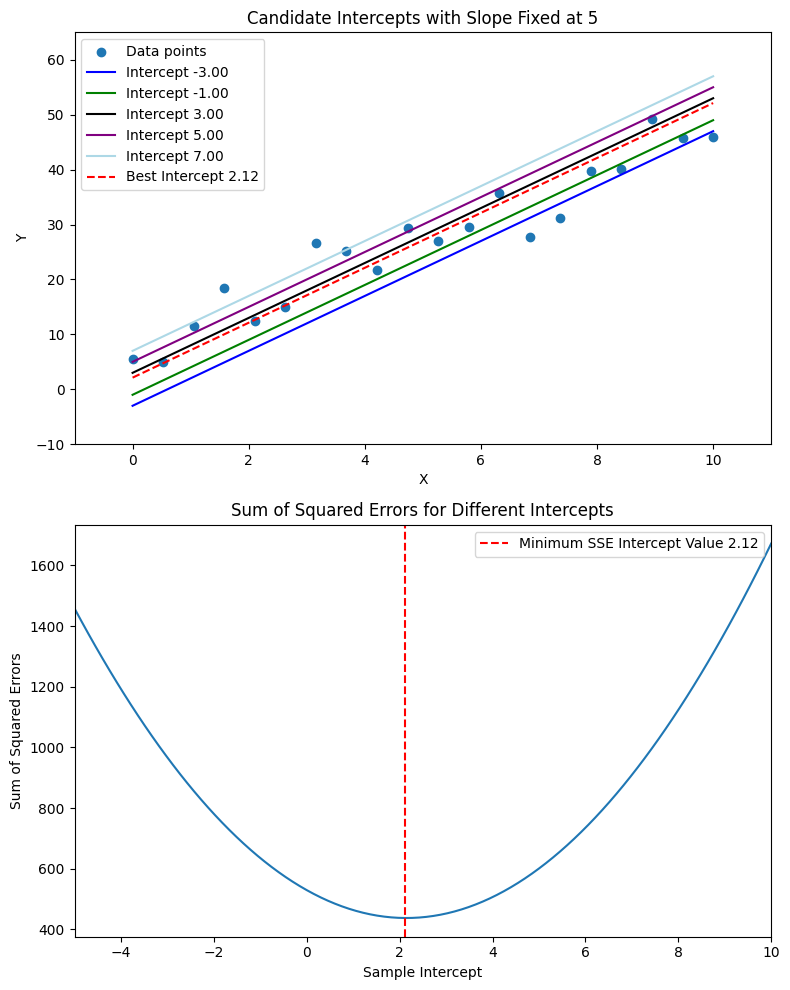

In [4]:
# Generate data following the population line y = 3 + 5x (slope = 5, intercept = 3)
np.random.seed(42)
X = np.linspace(0, 10, 20).reshape(-1, 1)
intercept_true = 3
slope = 5
y_true = intercept_true + slope * X.flatten()

# Adding some noise to simulate real-world data
y = y_true + np.random.normal(0, 5, size=y_true.shape)

# Fit a line of best fit using Linear Regression
model = LinearRegression(fit_intercept=True)
model.fit(X, y)
best_fit_intercept = model.coef_[0]
y_pred = model.predict(X)

# Prepare to plot scatter points and regression lines
intercepts = [-3, -1, 3, 5, 7]  # Different example intercepts
colors = ['blue', 'g', 'black', 'purple', 'lightblue']

# Calculate SSE for different intercepts
intercept_range = np.linspace(-5, 10, 100)
sse_values = []

for intercept in intercept_range:
    y_pred_intercept = intercept + slope * X.flatten()
    residuals = y - y_pred_intercept

    sse = np.sum(residuals ** 2)

    sse_values.append(sse)

#find intercept with smallest SSE
best_intercept = intercept_range[np.argmin(sse_values)]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# Scatter plot
ax1.scatter(X.flatten(), y, label='Data points')

#candidate regression lines
for intercept, color in zip(intercepts, colors):
  candidate_y = intercept + slope * X.flatten()

  ax1.plot(X.flatten(), candidate_y, label=f'Intercept {intercept:.2f}', color=color)

#best line when slope fixed at 5
best_fixed_y = best_intercept + slope * X.flatten()

ax1.plot(X, best_fixed_y, label=f'Best Intercept {best_intercept:.2f}', color='red', linestyle='--')

ax1.set_title('Candidate Intercepts with Slope Fixed at 5')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.legend()

#resizing
ax1.set_xlim(-1, 11)
ax1.set_ylim(-10, 65)
ax1.legend()

# SSE plot
ax2.plot(intercept_range, sse_values)

ax2.set_title('Sum of Squared Errors for Different Intercepts')
ax2.set_xlabel('Sample Intercept')
ax2.set_ylabel('Sum of Squared Errors')
ax2.axvline(best_intercept, color='red', linestyle='--', label=f'Minimum SSE Intercept Value {best_intercept:.2f}')

ax2.set_xlim(-5, 10)
ax2.legend()

plt.tight_layout()
plt.show()

##Solving normal equations from lecture example for $\beta_0$ and $\beta_1$:

**Solving for $\beta_0$:**

\begin{equation}
\sum_t y_t = Tb_0 + b_1\sum_tx_t
\end{equation}

First we move the x term to the left side of the equation:

\begin{equation}
\sum_t y_t - b_1\sum_tx_t= Tb_0
\end{equation}

We can divide the terms by T to leave us with the averages:

\begin{equation}
\frac{1}{T}
\sum_t y_t
-
b_1
\frac{1}{T}
\sum_tx_t
=
b_0
\frac{T}{T}
\end{equation}

These are by definition our sample average terms, so:

\begin{equation}
\bar{y} -
b_1\bar{x}
=
b_0
\end{equation}

**Solving for $b_1$:**

\begin{equation}
\sum_t y_tx_t = b_0\sum_tx_t + b_1\sum_tx_t^2
\end{equation}

Start by replacing $b_0$ with expression found earlier, so there are only $b_1$s:

\begin{equation}
\sum_t y_tx_t = (\bar{y} -
b_1\bar{x})\sum_tx_t + b_1\sum_tx_t^2
\end{equation}

Replace $\sum_tx_t$ with its equivalent $T\bar{x}$:

\begin{equation}
\sum_t y_tx_t = (\bar{y} -
b_1\bar{x})T\bar{x} + b_1\sum_tx_t^2
\end{equation}

Expand the polynomial:

\begin{equation}
\sum_t y_tx_t = \bar{y}T\bar{x} -
b_1\bar{x}T\bar{x} + b_1\sum_tx_t^2
\end{equation}

Put $b_1$ terms alone on one side:

\begin{equation}
\sum_t y_tx_t - T\bar{y}\bar{x} = -
b_1\bar{x}T\bar{x} + b_1\sum_tx_t^2
\end{equation}

Factor out $b_1$:

\begin{equation}
\sum_t y_tx_t - T\bar{y}\bar{x} =
b_1(-\bar{x}T\bar{x} + \sum_tx_t^2)
\end{equation}

Divide:

\begin{equation}
\frac{\sum_t y_tx_t - T\bar{y}\bar{x}}{\sum_tx_t^2 - \bar{x}T\bar{x}}=
b_1
\end{equation}

From here, I'll work backward. This is our end goal:

\begin{equation}
b_1 = \frac{\sum_t(y_t - \bar{y})(x_t - \bar{x})}{\sum_t(x_t - \bar{x})^2}
\end{equation}

I'll work on the numerator first. Expand the polynomial:

\begin{equation}
b_1 = \frac{\sum_t(y_tx_t - y_t\bar{x} - \bar{y}x_t + \bar{y}\bar{x})}{\sum_t(x_t - \bar{x})^2}
\end{equation}

Distribute the sum:

\begin{equation}
b_1 = \frac{\sum_ty_tx_t - \sum_ty_t\bar{x} - \sum_t\bar{y}x_t + \sum_t\bar{y}\bar{x}}{\sum_t(x_t - \bar{x})^2}
\end{equation}

Since $\bar{y}$ and $\bar{x}$ are constants, we can move them outside the sums:

\begin{equation}
b_1 = \frac{\sum_t y_t x_t
- \bar{x} \sum_t y_t
- \bar{y} \sum_t x_t
+ \sum_t \bar{y}\bar{x}
}{\sum_t (x_t - \bar{x})^2}
\end{equation}

Replacing sums with their equivalent bar notations, we get:

\begin{equation}
b_1 = \frac{\sum_t y_t x_t
- \bar{x}T\bar{y}
- \bar{y}T\bar{x}
+ T\bar{y}\bar{x}
}{\sum_t (x_t - \bar{x})^2}
\end{equation}

Combining like terms:
\begin{equation}
b_1 = \frac{\sum_t y_t x_t
- T\bar{x}\bar{y}
}{\sum_t (x_t - \bar{x})^2}
\end{equation}

Now, tackling the denominator, multiply out the terms and distribute the sum:

\begin{equation}
b_1 = \frac{\sum_t y_t x_t
- T\bar{x}\bar{y}
}{\sum_t x_t^2 - 2\sum_t x_t\bar{x} + \sum_t
\bar{x}^2}
\end{equation}

Pull out constant bar term:
\begin{equation}
b_1 = \frac{\sum_t y_t x_t
- T\bar{x}\bar{y}
}{\sum_t x_t^2 - 2\bar{x} \sum_t x_t + \sum_t
\bar{x}^2}
\end{equation}

Replace sums with bar notation:

\begin{equation}
b_1 = \frac{\sum_t y_t x_t
- T\bar{x}\bar{y}
}{\sum_t x_t^2 - 2T\bar{x}^2 +
T\bar{x}^2}
\end{equation}

Simplify:

\begin{equation}
b_1 = \frac{\sum_t y_t x_t
- T\bar{x}\bar{y}
}{\sum_t x_t^2 - T\bar{x}^2}
\end{equation}

This is the same as where we left off working forward:

\begin{equation}
\frac{\sum_t y_tx_t - T\bar{y}\bar{x}}{\sum_tx_t^2 - \bar{x}T\bar{x}}=
b_1
\end{equation}

Whew!!!!

## Covariance and Simultaneity
In the first lecture, we talked about how you can't just plot a bunch of observed prices and quantities and then expect to see the supply or demand curve mapped out. The reason is that the curves move simultaneously, and so those values could be on any number of theoretical demand or supply curves at any given time.

If we wanted to set up a simple linear regression model for demand that tried to correlate (P)rice and (Q)uantity (our "Y" and "X" values, respectively), it could look like this, where $\epsilon_d$ represents the things we can't see that might be affecting demand:

\begin{equation}
P = \beta_0 + \beta_1Q + \epsilon_d
\end{equation}

So then we might try to assume that, in this given market, quantity and the error term each move independently of the other and are therefore uncorrelated. If this were 100% true, this would mean that $COV(Q, \epsilon) = 0$, or:

\begin{equation}
COV(Q, \epsilon_d) =
\frac{1}{n}
\sum(Q - \bar{Q})(\epsilon - \bar{\epsilon})
=
0
\end{equation}

Especially in complex scenarios with many variables, it seems unlikely that no one parameter is affected in any way by any other. In this example, quantity and price are not only moving in relationship to a theoretical demand curve, they are also somewhere on an intersecting supply curve. We could model a supply curve in a similar way to the demand curve:

\begin{equation}
P = \alpha_0 + \alpha_1Q + \epsilon_s
\end{equation}

At equilibrium, that is, at all observed quantities and prices, the supply and demand curves have to equal each other. And so we could say:  

\begin{equation}
\beta_0 + \beta_1Q + \epsilon_d
=
\alpha_0 + \alpha_1Q + \epsilon_s
\end{equation}

So if we are trying to use quantity to predict price, we could isolate Q by first moving the Q terms to one side, factoring out Q and dividing by the rest of the terms:

\begin{equation}
Q
=
\frac{\beta_0 - \alpha_0 - \epsilon_s + \epsilon_d}
{\alpha_1 - \beta_1}
\end{equation}

This is the equation that was used in the simultaneity simulations in the first lecture. The structure and function of this equation shows that  Q is now at least partially determined by $\epsilon_d$, which means that Q itself is going to be affected by those unseen factors quantified in that $\epsilon_d$. This means that they will move together, and the likelihood that the covariance of Q and $\epsilon_d$ is going to be zero is just about...zero.



We can plug these equations directly into the covariance definition to see this more clearly:

\begin{equation}
COV(Q, \epsilon_d) =
\frac{1}{n}
\sum(Q - \bar{Q})(\epsilon_d - \bar{\epsilon_d})
\end{equation}

We already defined Q as:
\begin{equation}
Q
=
\frac{\beta_0 - \alpha_0 - \epsilon_s + \epsilon_d}
{\alpha_1 - \beta_1}
\end{equation}
so $\bar{Q}$ would be (the alphas and betas are constants):

\begin{equation}
\bar{Q}
=
\frac{\beta_0 - \alpha_0 - \bar{\epsilon_s} + \bar{\epsilon_d}}
{\alpha_1 - \beta_1}
\end{equation}

When we plug them into the covariance equation:

\begin{equation}
COV(Q, \epsilon_d) =
\frac{1}{n}
\sum(\frac{\beta_0 - \alpha_0 - \epsilon_s + \epsilon_d}
{\alpha_1 - \beta_1} -
\frac{\beta_0 - \alpha_0 - \bar{\epsilon_s} + \bar{\epsilon_d}}
{\alpha_1 - \beta_1}
(\epsilon_d - \bar{\epsilon_d}))
\end{equation}

When we combine the two ugly fractions and stick similar terms together, we get:

\begin{equation}
COV(Q, \epsilon_d) =
\frac{1}{n}
\sum(\frac{\epsilon_s - \bar{\epsilon_s} - \epsilon_d + \bar{\epsilon_d}}
{\alpha_1 - \beta_1}
(\epsilon_d - \bar{\epsilon_d}))
\end{equation}

The remaining alphas and betas are constant, so we can pull them out of the sum:

\begin{equation}
COV(Q, \epsilon_d) =
\frac{1}{n(\alpha_1 - \beta_1)}
\sum(\epsilon_s - \bar{\epsilon_s} - \epsilon_d + \bar{\epsilon_d})
(\epsilon_d - \bar{\epsilon_d})
\end{equation}


Recognizing that the remaining terms in the sum are the covariance and variance terms for the errors, we get:

\begin{equation}
COV(Q, \epsilon_d) =
\frac{1}{(\alpha_1 - \beta_1)} (
COV(\epsilon_d, \epsilon_s) - VAR (\epsilon_d))
\end{equation}

Making it neater:

\begin{equation}
COV(Q, \epsilon_d) =
\frac{COV(\epsilon_d, \epsilon_s) - VAR (\epsilon_d))}
{(\alpha_1 - \beta_1)}
\end{equation}

To see what happens when we set the $COV(Q, \epsilon_d) = 0$:
\begin{equation}
\frac{COV(\epsilon_d, \epsilon_s) - VAR (\epsilon_d))}
{(\alpha_1 - \beta_1)}
= 0
\end{equation}

so:
\begin{equation}
COV(\epsilon_d, \epsilon_s) - VAR (\epsilon_d)
= 0
\end{equation}

and:

\begin{equation}
COV(\epsilon_d, \epsilon_s) = VAR (\epsilon_d)
\end{equation}

This means that unless the covariance of $\epsilon_d$ and $\epsilon_s$ is exactly equal to the variance of $\epsilon_d$ (which always has to be non-negative because it is a squared value), the equation is false and

\begin{equation}
COV(Q, \epsilon_d)
\neq
0
\end{equation}

The equation would only hold true in the unlikely case that some positive variance of $\epsilon_d$ happens to equal the covariance of Q and $\epsilon_d$, which includes the case when $VAR(\epsilon_d) = 0$. This can occur if $\epsilon_d$ itself = 0, but will also happen anytime $\epsilon_d$ is held fixed across observations. When this happens, it will also follow that the $COV(Q, \epsilon_d)$ must also be 0, since the $\epsilon_d - \bar{\epsilon_d}$ terms will be exactly the same.

I am guessing that this is exactly the way that we hold the demand curve steady: by eliminating any variance in $\epsilon_d$! This would allow us to better understand the demand curve, because only supply shocks would be moving the price and quantity points. As shown in the first lecture, reducing demand shocks as close to 0 as possible allowed for better recognition of the movement of prices/quantity along the demand curve. And, if we wanted to understand the supply curve, we would do the same thing: hold the supply curve steady, (probably by reducing variance in $\epsilon_s$) in order to reduce the effects supply shocks might have on the observed values.  